In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:

# Data
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Sigmoid + its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(a):
    # NOTE: input is already sigmoid(x)
    return a * (1 - a)


In [30]:

# Init
np.random.seed(1)
input_neurons = 2
hidden_neurons = 2
output_neurons = 1
W1 = np.random.randn(input_neurons,hidden_neurons)
b1 = np.zeros((1,hidden_neurons))

W2 = np.random.randn(hidden_neurons,output_neurons)
b2 = np.zeros((1,output_neurons))

lr = 0.1

# Grid for visualization
xx, yy = np.meshgrid(np.linspace(-0.5,1.5,100),
                     np.linspace(-0.5,1.5,100))


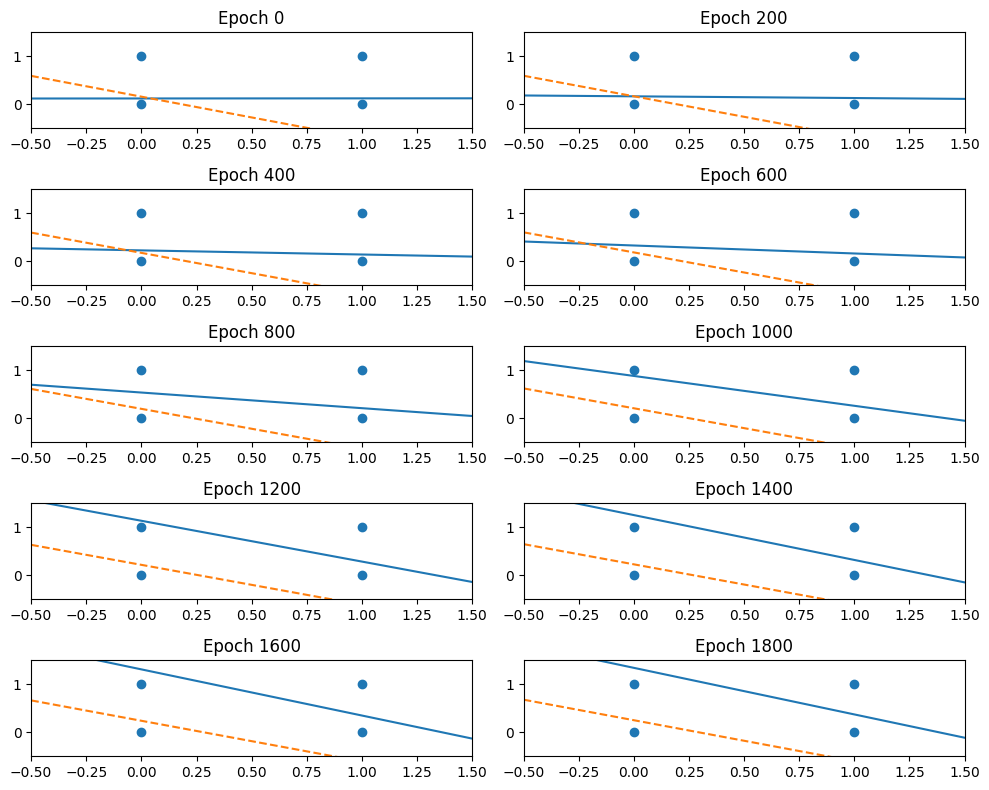

In [33]:
# BEFORE loop (keep this once)
plt.figure(figsize=(10,8))
plot_num = 1
x_vals = np.linspace(-0.5, 1.5, 100)

for epoch in range(2000):

    # Forward pass
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    # Error
    error = y - a2

    # Backprop
    d2 = error * sigmoid_derivative(a2)
    d1 = d2 @ W2.T * sigmoid_derivative(a1)

    # Update
    W2 += a1.T @ d2 * lr
    b2 += np.sum(d2, axis=0, keepdims=True) * lr
    W1 += X.T @ d1 * lr
    b1 += np.sum(d1, axis=0, keepdims=True) * lr

    # ✅ Plot lines instead of contour
    if epoch % 200 == 0:

        plt.subplot(5, 2, plot_num)
        plot_num += 1

        # --- Line 1 ---
        w1, w2 = W1[0,0], W1[1,0]
        b = b1[0,0]
        y_vals = -(w1 * x_vals + b) / (w2 + 1e-8)
        plt.plot(x_vals, y_vals, label="N1")

        # --- Line 2 ---
        w1, w2 = W1[0,1], W1[1,1]
        b = b1[0,1]
        y_vals = -(w1 * x_vals + b) / (w2 + 1e-8)
        plt.plot(x_vals, y_vals, linestyle='dashed', label="N2")

        # Data points
        plt.scatter(X[:,0], X[:,1])

        plt.title(f"Epoch {epoch}")
        plt.xlim(-0.5, 1.5)
        plt.ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()